In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel file
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Data Analyst\Blinkit Project\Excel\BlinkIT Grocery Data.xlsx")

# Display first 5 rows
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


Understand the dataset

In [3]:
# Number of rows and columns
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

Shape: (8523, 12)

Columns:
['Item Fat Content', 'Item Identifier', 'Item Type', 'Outlet Establishment Year', 'Outlet Identifier', 'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility', 'Item Weight', 'Sales', 'Rating']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight 

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.857645,140.992783,3.965857
std,3.189396,0.051598,4.643456,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,8.773750,93.826500,4.000000
50%,2016.000000,0.053931,12.600000,143.012800,4.000000
75%,2018.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


Check missing values

In [4]:
# Missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)

Missing Values:
Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

Missing Value Percentage:
Item Fat Content              0.000000
Item Identifier               0.000000
Item Type                     0.000000
Outlet Establishment Year     0.000000
Outlet Identifier             0.000000
Outlet Location Type          0.000000
Outlet Size                   0.000000
Outlet Type                   0.000000
Item Visibility               0.000000
Item Weight                  17.165317
Sales                         0.000000
Rating                        0.000000
dtype: float64


Check duplicate records

In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (8523, 12)


Clean column names

In [6]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')


Check unique values

In [7]:
for column in df.select_dtypes(include="object").columns:
    print("\n", column)
    print(df[column].unique())


 Item Fat Content
['Regular' 'Low Fat' 'low fat' 'LF' 'reg']

 Item Identifier
['FDX32' 'NCB42' 'FDR28' ... 'FDU60' 'NCX53' 'FDE52']

 Item Type
['Fruits and Vegetables' 'Health and Hygiene' 'Frozen Foods' 'Canned'
 'Soft Drinks' 'Household' 'Snack Foods' 'Meat' 'Breads' 'Hard Drinks'
 'Others' 'Dairy' 'Breakfast' 'Baking Goods' 'Seafood' 'Starchy Foods']

 Outlet Identifier
['OUT049' 'OUT018' 'OUT046' 'OUT013' 'OUT045' 'OUT017' 'OUT010' 'OUT027'
 'OUT035' 'OUT019']

 Outlet Location Type
['Tier 1' 'Tier 3' 'Tier 2']

 Outlet Size
['Medium' 'Small' 'High']

 Outlet Type
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


Basic KPIs

In [8]:
total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
average_rating = df["Rating"].mean()
total_items = df["Item Identifier"].nunique()
total_outlets = df["Outlet Identifier"].nunique()

print("===== KEY PERFORMANCE INDICATORS =====")
print("Total Sales:", round(total_sales, 2))
print("Average Sales:", round(average_sales, 2))
print("Average Rating:", round(average_rating, 2))
print("Total Products:", total_items)
print("Total Outlets:", total_outlets)

===== KEY PERFORMANCE INDICATORS =====
Total Sales: 1201681.49
Average Sales: 140.99
Average Rating: 3.97
Total Products: 1559
Total Outlets: 10


Sales by Item Type

Item Type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9224
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4616
Canned                    90706.7290
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1670
Breads                    35379.1198
Hard Drinks               29334.6806
Others                    22451.8916
Starchy Foods             21880.0274
Breakfast                 15596.6966
Seafood                    9077.8700
Name: Sales, dtype: float64


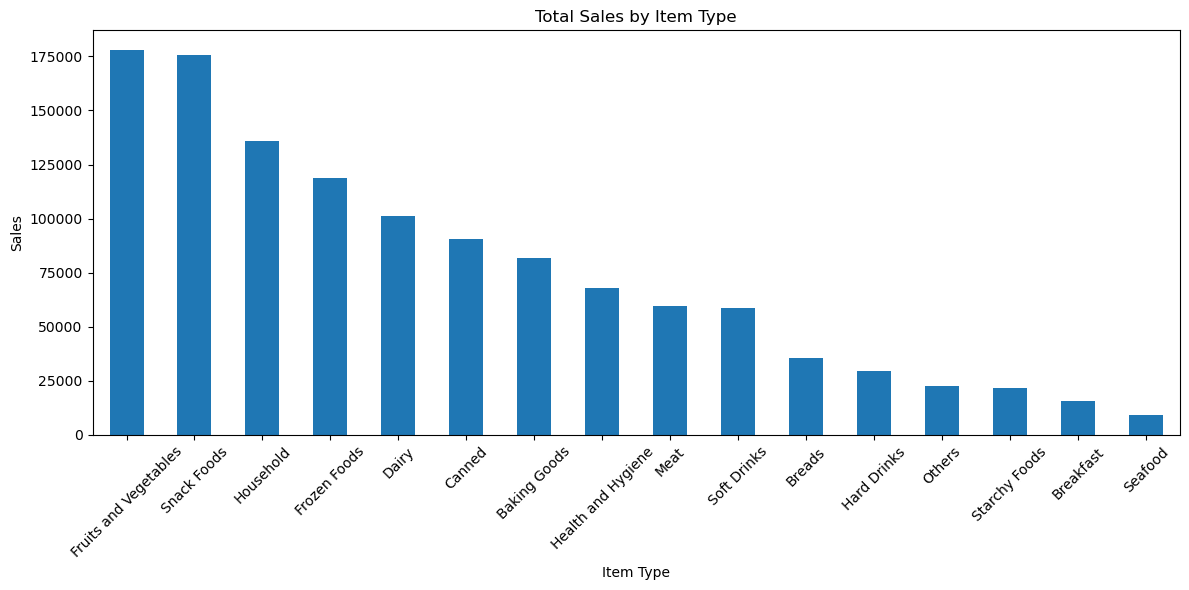

In [9]:
item_sales = df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)

print(item_sales)

plt.figure(figsize=(12, 6))
item_sales.plot(kind="bar")
plt.title("Total Sales by Item Type")
plt.xlabel("Item Type")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales by Fat Content

Item Fat Content
Low Fat    717390.8474
Regular    409413.1234
LF          43857.1082
reg         15948.6810
low fat     15071.7328
Name: Sales, dtype: float64


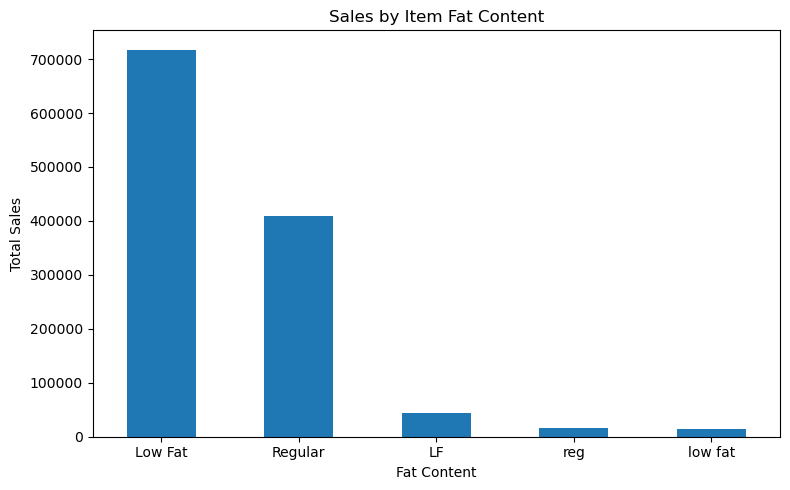

In [10]:
fat_sales = df.groupby("Item Fat Content")["Sales"].sum().sort_values(ascending=False)

print(fat_sales)

plt.figure(figsize=(8, 5))
fat_sales.plot(kind="bar")
plt.title("Sales by Item Fat Content")
plt.xlabel("Fat Content")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sales by Outlet Type

Outlet Type
Supermarket Type1    787549.8928
Grocery Store        151939.1490
Supermarket Type2    131477.7764
Supermarket Type3    130714.6746
Name: Sales, dtype: float64


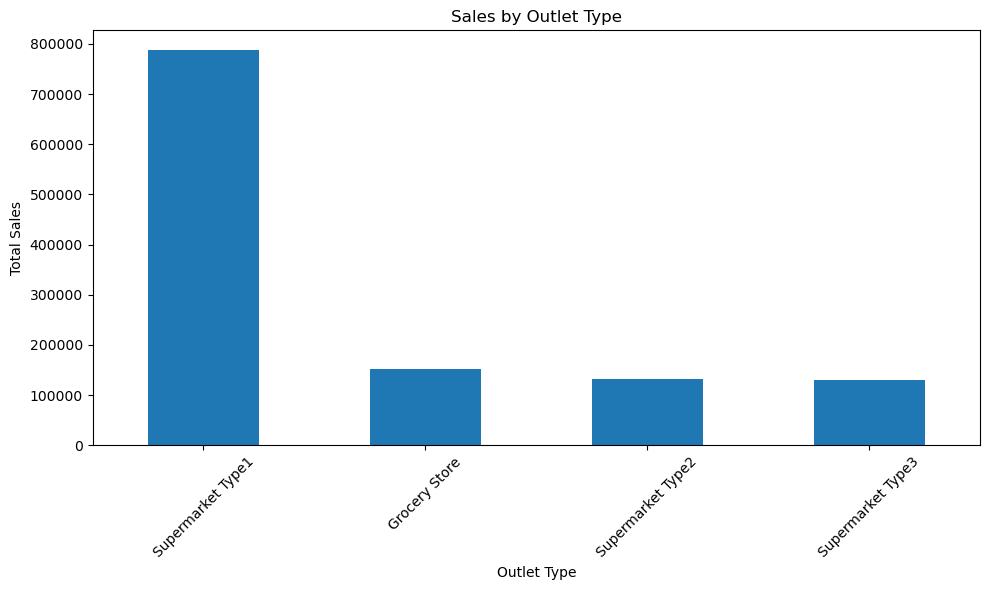

In [11]:
outlet_sales = df.groupby("Outlet Type")["Sales"].sum().sort_values(ascending=False)

print(outlet_sales)

plt.figure(figsize=(10, 6))
outlet_sales.plot(kind="bar")
plt.title("Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales by Outlet Location

Outlet Location Type
Tier 3    472133.0332
Tier 2    393150.6476
Tier 1    336397.8120
Name: Sales, dtype: float64


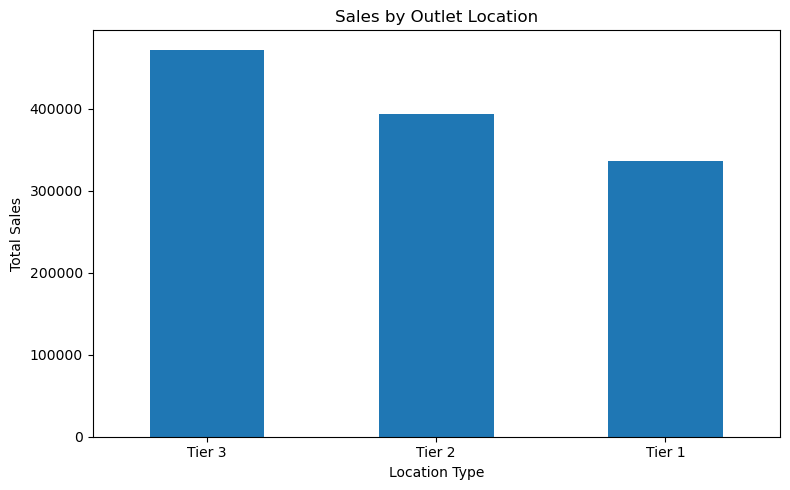

In [12]:
location_sales = df.groupby("Outlet Location Type")["Sales"].sum().sort_values(ascending=False)

print(location_sales)

plt.figure(figsize=(8, 5))
location_sales.plot(kind="bar")
plt.title("Sales by Outlet Location")
plt.xlabel("Location Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sales by Outlet Size

Outlet Size
Medium    507895.7364
Small     444794.1704
High      248991.5860
Name: Sales, dtype: float64


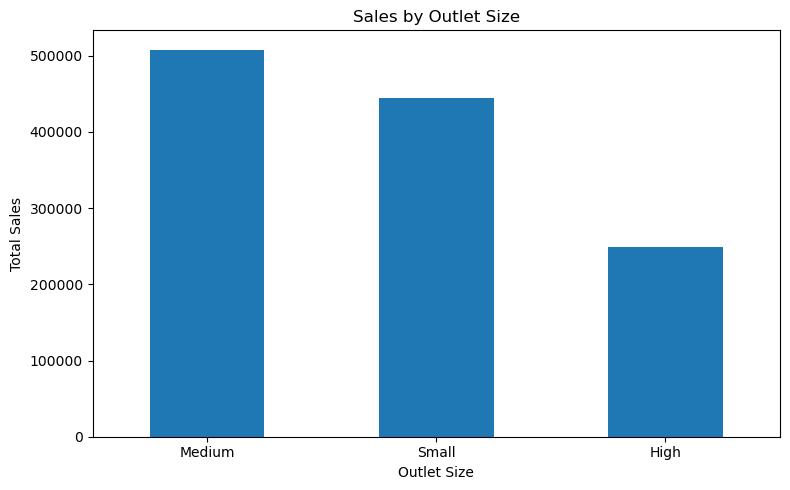

In [13]:
size_sales = df.groupby("Outlet Size")["Sales"].sum().sort_values(ascending=False)

print(size_sales)

plt.figure(figsize=(8, 5))
size_sales.plot(kind="bar")
plt.title("Sales by Outlet Size")
plt.xlabel("Outlet Size")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sales by Establishment Year

Outlet Establishment Year
2011     78131.5666
2012    130476.8598
2014    131809.0156
2015    130942.7802
2016    132113.3698
2017    133103.9070
2018    204522.2570
2020    129103.9604
2022    131477.7764
Name: Sales, dtype: float64


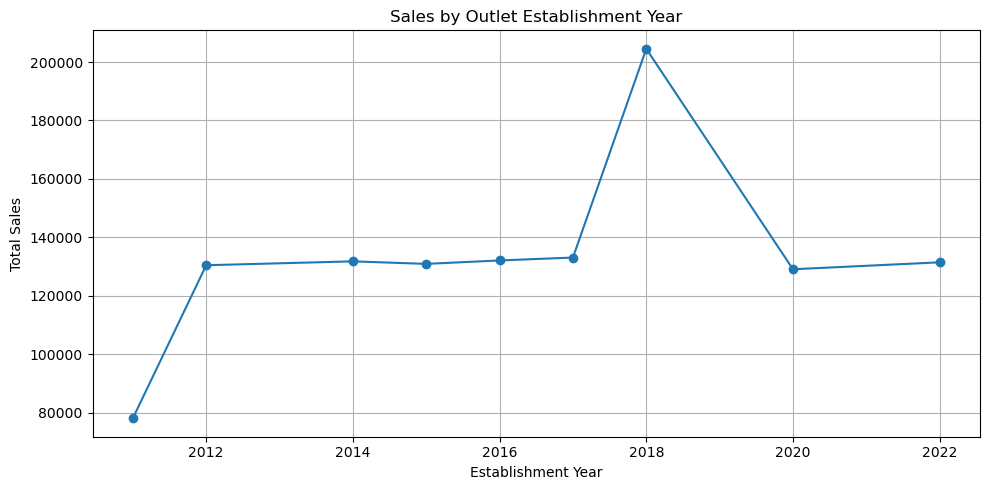

In [15]:
year_sales = df.groupby("Outlet Establishment Year")["Sales"].sum()

print(year_sales)

plt.figure(figsize=(10, 5))
year_sales.plot(kind="line", marker="o")
plt.title("Sales by Outlet Establishment Year")
plt.xlabel("Establishment Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

Top 10 products by sales

Item Identifier
FDU12    2371.0112
FDT07    2306.8970
NCQ06    2294.7126
FDL58    2111.6544
NCB31    2104.7280
FDX31    2104.4622
FDF05    2103.1280
FDR59    2096.5752
FDP28    2087.8488
FDA04    2072.0696
Name: Sales, dtype: float64


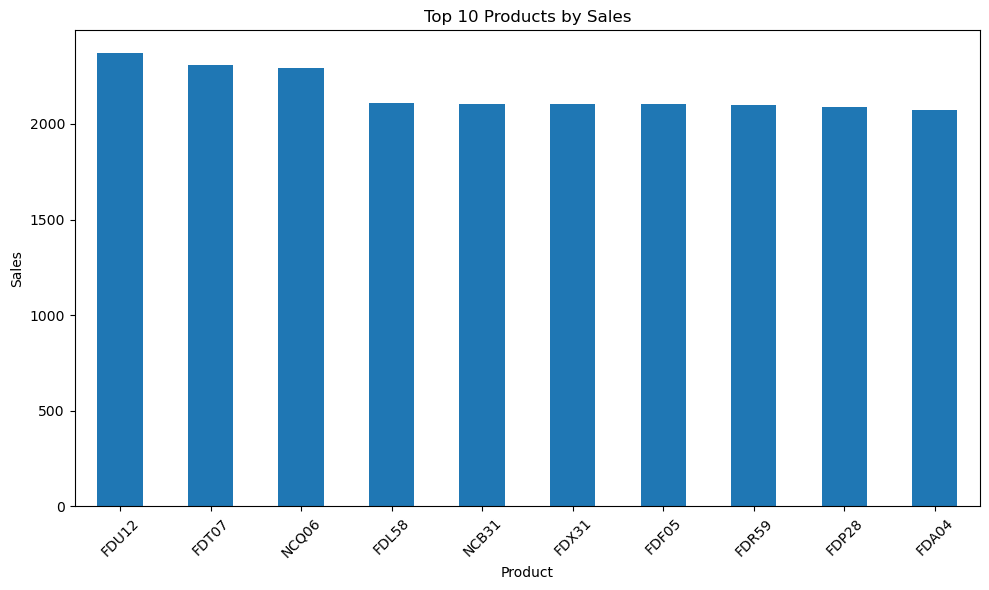

In [16]:
top_products = (
    df.groupby("Item Identifier")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

plt.figure(figsize=(10, 6))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Item visibility vs sales

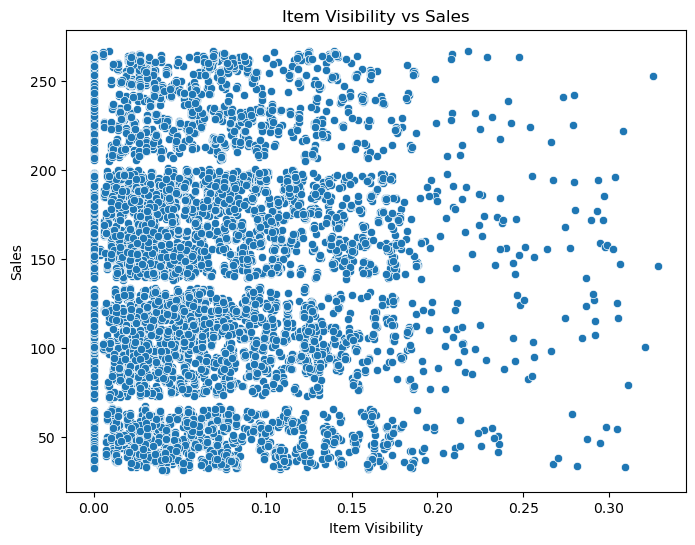

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Item Visibility",
    y="Sales"
)

plt.title("Item Visibility vs Sales")
plt.xlabel("Item Visibility")
plt.ylabel("Sales")
plt.show()

Item weight vs sales

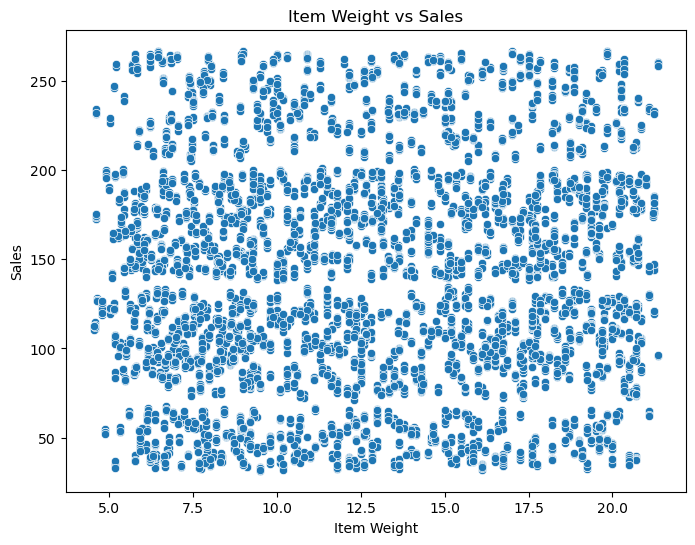

In [18]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Item Weight",
    y="Sales"
)

plt.title("Item Weight vs Sales")
plt.xlabel("Item Weight")
plt.ylabel("Sales")
plt.show()

Rating distribution

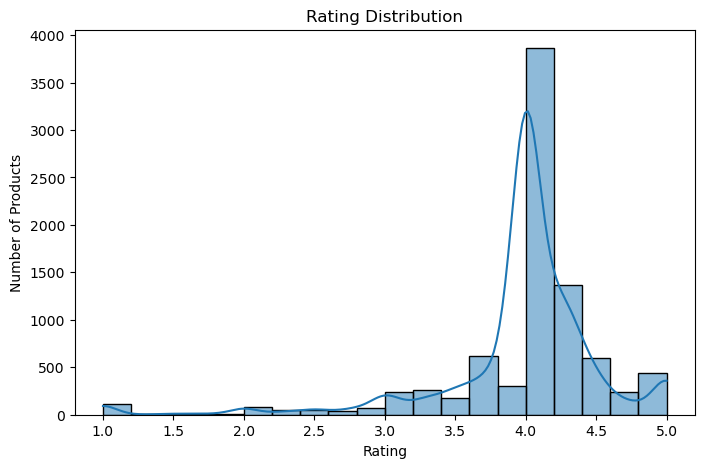

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()

Sales distribution

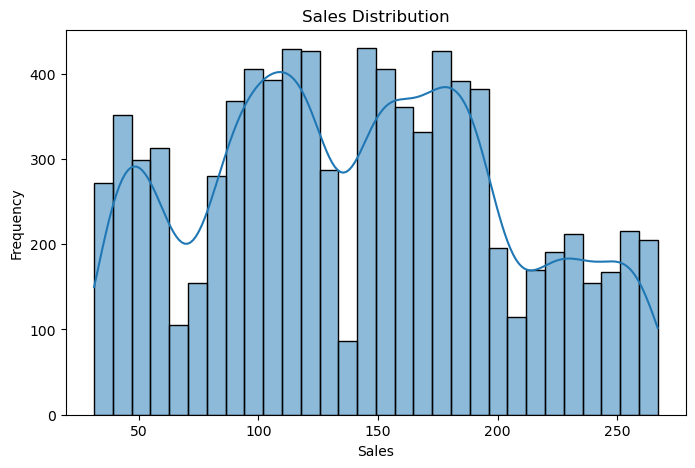

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Sales"],
    bins=30,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Correlation heatmap

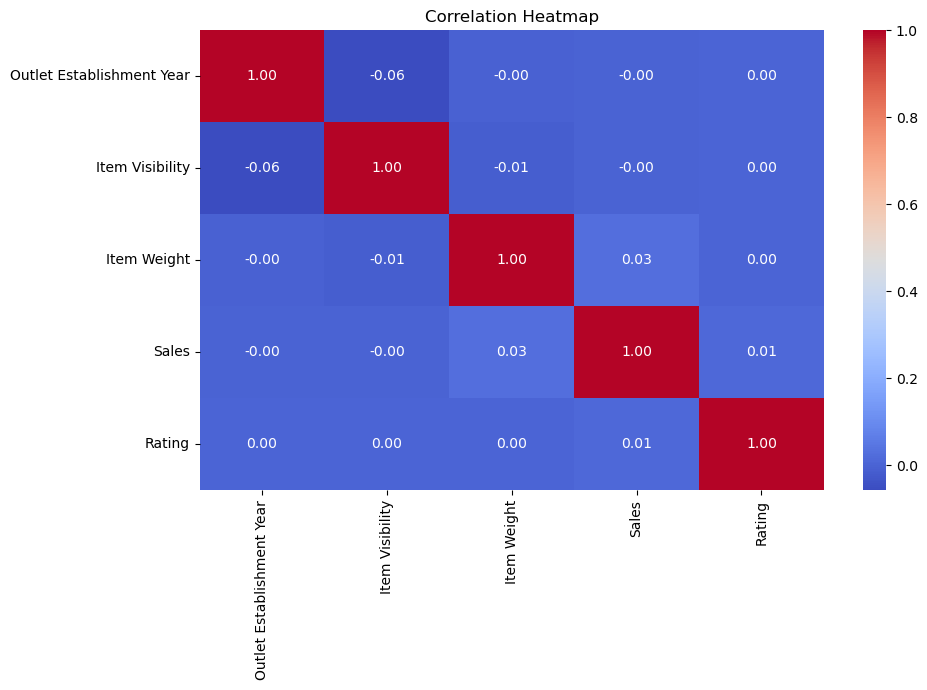

In [21]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Average sales by outlet type

Outlet Type
Supermarket Type2    141.678638
Supermarket Type1    141.213895
Grocery Store        140.294690
Supermarket Type3    139.801791
Name: Sales, dtype: float64


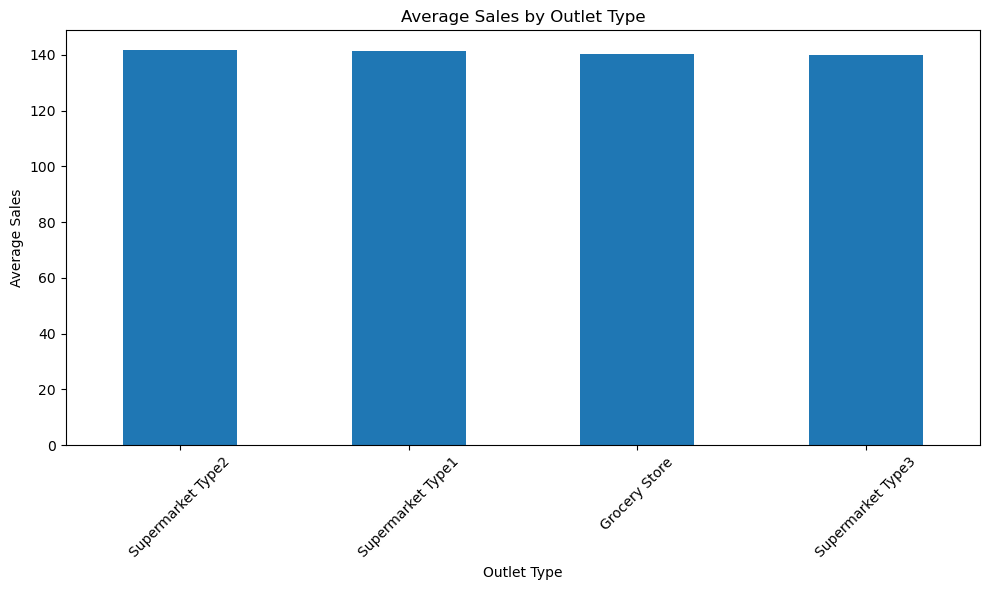

In [23]:
avg_outlet_sales = (
    df.groupby("Outlet Type")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_outlet_sales)

plt.figure(figsize=(10, 6))
avg_outlet_sales.plot(kind="bar")
plt.title("Average Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Item type and fat content analysis

Item Fat Content              LF      Low Fat     Regular    low fat  \
Item Type                                                              
Baking Goods           2312.8286   36507.1296  40793.2080   833.0526   
Breads                  964.1152   17421.3834  16250.9858   456.0072   
Breakfast               277.0728    6498.5738   8666.9160        NaN   
Canned                 2107.7990   43911.7216  41702.8954  1567.8880   
Dairy                  3146.5288   56579.8548  38820.7876  1768.1016   
Frozen Foods           3559.2326   58539.2386  53400.1592   460.2994   
Fruits and Vegetables  5519.9240   79140.4378  88087.5500  1371.2216   
Hard Drinks            1095.2752   27418.6398         NaN   820.7656   
Health and Hygiene     3929.2360   63041.0466         NaN  1055.5562   
Household              7875.7798  125627.8934         NaN  2472.8522   
Meat                   1193.3188   20832.2240  35898.8338   244.2512   
Others                 1577.3958   20779.2154         NaN    95.

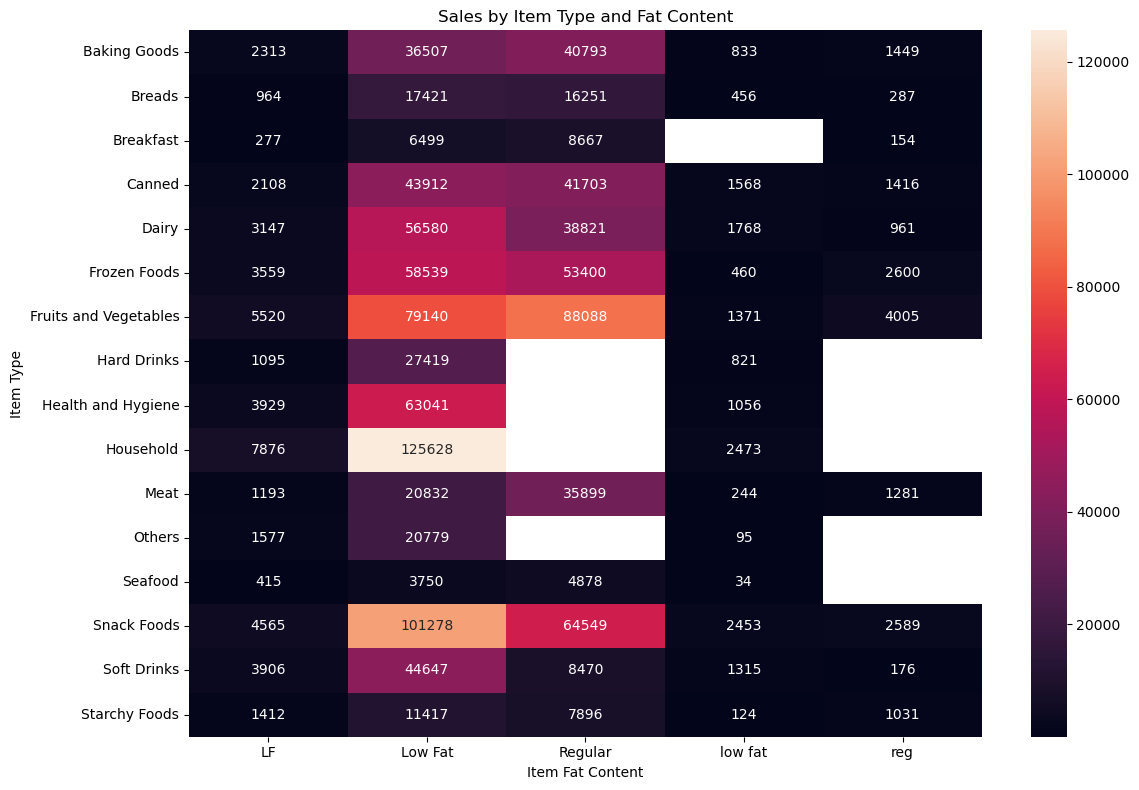

In [24]:
pivot_table = pd.pivot_table(
    df,
    values="Sales",
    index="Item Type",
    columns="Item Fat Content",
    aggfunc="sum"
)

print(pivot_table)

plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f"
)

plt.title("Sales by Item Type and Fat Content")
plt.tight_layout()
plt.show()

Top 10 outlets by sales

Outlet Identifier
OUT035    133103.9070
OUT046    132113.3698
OUT013    131809.0156
OUT018    131477.7764
OUT045    130942.7802
OUT027    130714.6746
OUT049    130476.8598
OUT017    129103.9604
OUT010     78131.5666
OUT019     73807.5824
Name: Sales, dtype: float64


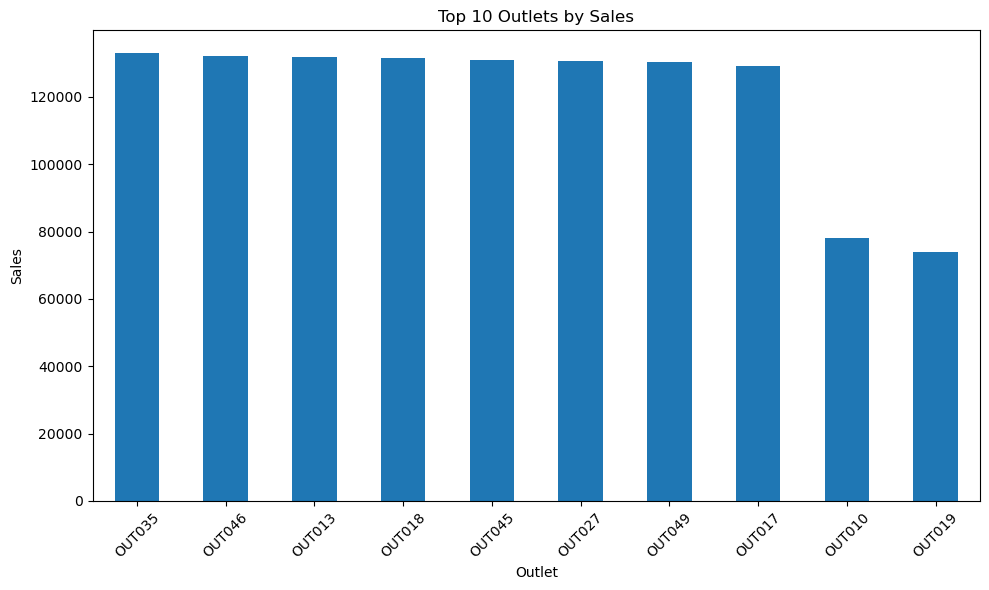

In [25]:
top_outlets = (
    df.groupby("Outlet Identifier")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_outlets)

plt.figure(figsize=(10, 6))
top_outlets.plot(kind="bar")
plt.title("Top 10 Outlets by Sales")
plt.xlabel("Outlet")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Final business insights

In [26]:
best_item = item_sales.idxmax()
best_outlet = outlet_sales.idxmax()
best_location = location_sales.idxmax()
best_size = size_sales.idxmax()
best_fat_content = fat_sales.idxmax()

print("========== BUSINESS INSIGHTS ==========")

print(f"1. Best performing item category: {best_item}")

print(f"2. Highest sales outlet type: {best_outlet}")

print(f"3. Highest sales location type: {best_location}")

print(f"4. Highest sales outlet size: {best_size}")

print(f"5. Highest sales fat-content category: {best_fat_content}")

print(f"6. Average product rating: {average_rating:.2f}")

print(f"7. Total sales generated: {total_sales:,.2f}")

========== BUSINESS INSIGHTS ==========
1. Best performing item category: Fruits and Vegetables
2. Highest sales outlet type: Supermarket Type1
3. Highest sales location type: Tier 3
4. Highest sales outlet size: Medium
5. Highest sales fat-content category: Low Fat
6. Average product rating: 3.97
7. Total sales generated: 1,201,681.49


Export analysis results to Excel

In [27]:
with pd.ExcelWriter("BlinkIT_Python_Analysis.xlsx") as writer:

    item_sales.to_frame("Total Sales").to_excel(
        writer,
        sheet_name="Item Type Sales"
    )

    outlet_sales.to_frame("Total Sales").to_excel(
        writer,
        sheet_name="Outlet Type Sales"
    )

    location_sales.to_frame("Total Sales").to_excel(
        writer,
        sheet_name="Location Sales"
    )

    size_sales.to_frame("Total Sales").to_excel(
        writer,
        sheet_name="Outlet Size Sales"
    )

    top_products.to_frame("Total Sales").to_excel(
        writer,
        sheet_name="Top Products"
    )

print("Analysis exported successfully!")

Analysis exported successfully!
